# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [10]:
import pandas as pd
import numpy as np
import gdown
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
url='https://drive.google.com/uc?id=14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw&export=download'

output='checker-submits.csv'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw&export=download
To: /home/mirshod/Desktop/DSB10_Intro_to_ML.ID_886521-1/src/ex02/checker-timestamp.csv
100%|██████████| 77.0k/77.0k [00:00<00:00, 373kB/s]


'checker-timestamp.csv'

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [ ]:
df=pd.read_csv('checker-submits.csv')
df.head()

,uid,labname,numTrials,timestamp
0,user_4,project1,1,2020-04-17 05:19:02.744528
1,user_4,project1,2,2020-04-17 05:22:45.549397
2,user_4,project1,3,2020-04-17 05:34:24.422370
3,user_4,project1,4,2020-04-17 05:43:27.773992
4,user_4,project1,5,2020-04-17 05:46:32.275104


In [13]:
df['timestamp']=df['timestamp'].astype('datetime64[ns]')
df['hour']=df['timestamp'].dt.hour
df['dayofweek']=df['timestamp'].dt.weekday
df['target']=df['dayofweek']<5
df.drop('timestamp',axis=1,inplace=True)
df.head()

,uid,labname,numTrials,hour,dayofweek,target
0,user_4,project1,1,5,4,True
1,user_4,project1,2,5,4,True
2,user_4,project1,3,5,4,True
3,user_4,project1,4,5,4,True
4,user_4,project1,5,5,4,True


In [14]:
target=df['target']
cat_data=df[[ 'uid', 'labname']]
cat_data.head()

,uid,labname
0,user_4,project1
1,user_4,project1
2,user_4,project1
3,user_4,project1
4,user_4,project1


In [15]:
num_data=df[['numTrials','hour','dayofweek']]
num_data.head()

,numTrials,hour,dayofweek
0,1,5,4
1,2,5,4
2,3,5,4
3,4,5,4
4,5,5,4


In [16]:
num_scaled=StandardScaler().fit_transform(num_data)
num_scaled=pd.DataFrame(num_scaled,columns=num_data.columns)
num_scaled.head()

,numTrials,hour,dayofweek
0,-0.788667,-2.562352,0.321862
1,-0.756764,-2.562352,0.321862
2,-0.724861,-2.562352,0.321862
3,-0.692958,-2.562352,0.321862
4,-0.661055,-2.562352,0.321862


In [17]:
encoder = OneHotEncoder(handle_unknown='ignore')
cat_encoded = encoder.fit_transform(cat_data)
cat_encoded_df = pd.DataFrame(cat_encoded.toarray(), columns=encoder.get_feature_names_out(cat_data.columns))
cat_encoded_df.head()

,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [18]:
dayofweek=pd.concat([num_scaled, cat_encoded_df, target], axis=1)
dayofweek.head()

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1,target
0,-0.788667,-2.562352,0.321862,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True
1,-0.756764,-2.562352,0.321862,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True
2,-0.724861,-2.562352,0.321862,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True
3,-0.692958,-2.562352,0.321862,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True
4,-0.661055,-2.562352,0.321862,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True


In [19]:
dayofweek.to_csv('dayofweek.csv')

## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`.
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [21]:
def feature_importance(model, feature_names, title='Feature importance', n=10):
  importances=model.coef_
  importances_abs=np.abs(importances)
  importances_sum=np.sum(importances_abs,axis=0)
  importances_sum=importances_sum/np.sum(importances_sum)
  indices = np.argsort(importances_sum)[::-1]
  plt.figure(figsize=(10,10))
  plt.title(title)
  # Plot only the top 'n' features
  plt.barh(range(n), importances_sum[indices][:n],
           color="r", align="center")
  # Label the y-axis with the actual feature names for the top 'n' features
  plt.yticks(range(n), feature_names[indices][:n])
  plt.gca().invert_yaxis() # To show the most important feature at the top
  plt.show()

In [22]:
processed_data=pd.read_csv('dayofweek.csv')
processed_data.head()

,Unnamed: 0,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,...,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1,target
0,0,-0.788667,-2.562352,0.321862,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True
1,1,-0.756764,-2.562352,0.321862,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True
2,2,-0.724861,-2.562352,0.321862,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True
3,3,-0.692958,-2.562352,0.321862,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True
4,4,-0.661055,-2.562352,0.321862,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True


In [23]:
y=processed_data['target']
processed_data.drop('target',axis=1,inplace=True)
processed_data.drop('Unnamed: 0',axis=1,inplace=True)
X=processed_data

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [25]:
logreg=LogisticRegression(random_state=21,fit_intercept=False)
logreg.fit(X_train,y_train)

LogisticRegression(fit_intercept=False, random_state=21)

In [26]:
acc_score=accuracy_score(y_test,logreg.predict(X_test))
print(f'Accuracy: {(acc_score*100):.2f}')

Accuracy: 99.70


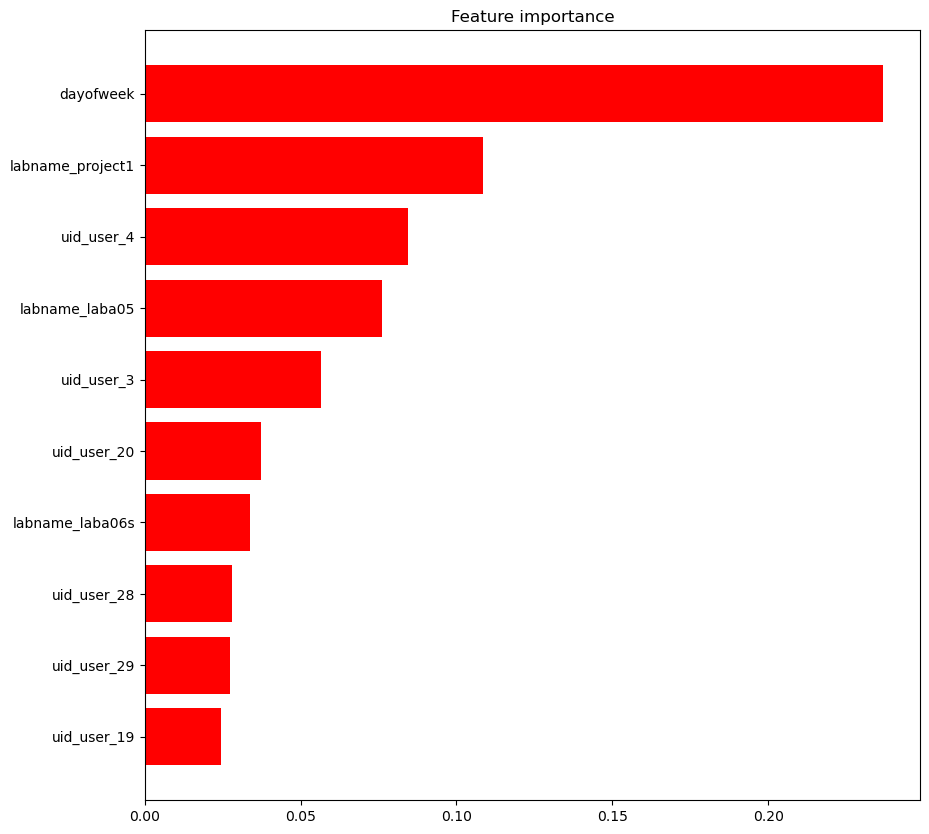

In [27]:
feature_importance(model=logreg, feature_names=X.columns)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`.
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [28]:
from sklearn.multiclass import OneVsRestClassifier

In [29]:
svc_linear=OneVsRestClassifier(SVC(kernel='linear',probability=True,random_state=21))
svc_linear.fit(X_train,y_train)

OneVsRestClassifier(estimator=SVC(kernel='linear', probability=True,
                                  random_state=21))

In [30]:
acc_score=accuracy_score(y_test,svc_linear.predict(X_test))
print(f'Accuracy: {(acc_score*100):.2f}')

Accuracy: 100.00


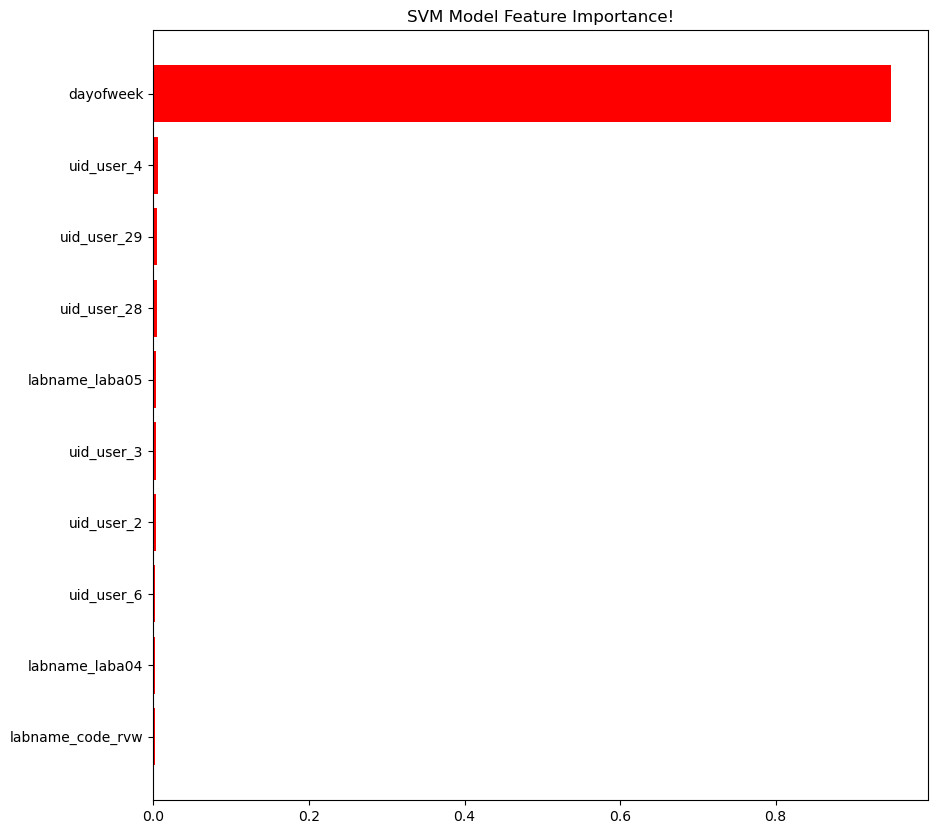

In [ ]:
n=10
feature_names=X.columns
importances=svc_linear.estimators_[0].coef_
importances_abs=np.abs(importances)
importances_sum=np.sum(importances_abs,axis=0)
importances_sum=importances_sum/np.sum(importances_sum)
indices = np.argsort(importances_sum)[::-1]
plt.figure(figsize=(10,10))
plt.title('SVM Model Feature Importance!')

plt.barh(range(n), importances_sum[indices][:n],
         color="r", align="center")

plt.yticks(range(n), feature_names[indices][:n])
plt.gca().invert_yaxis()
plt.show()

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`.
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [32]:
tree_model=DecisionTreeClassifier(max_depth=4,random_state=21)
tree_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=4, random_state=21)

In [33]:
acc_score=accuracy_score(y_test,tree_model.predict(X_test))
print(f'Accuracy: {(acc_score*100):.2f}')

Accuracy: 100.00


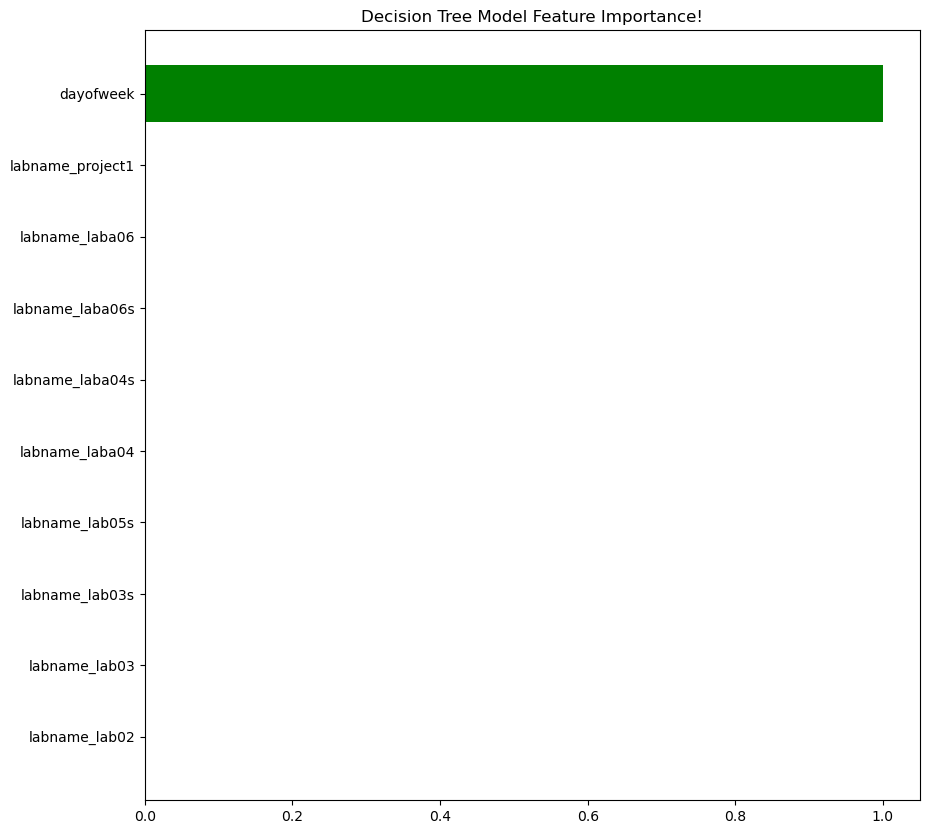

In [ ]:
n = 10
feature_names = X_train.columns
importances = tree_model.feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,10))
plt.title('Decision Tree Model Feature Importance!')

plt.barh(range(n), importances[indices][:n],
         color="g", align="center")

plt.yticks(range(n), feature_names[indices][:n])
plt.gca().invert_yaxis()
plt.show()

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`.
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [35]:
ran_forest_model=RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
ran_forest_model.fit(X_train,y_train)

RandomForestClassifier(max_depth=25, random_state=21)

In [36]:
acc_score=accuracy_score(y_test,ran_forest_model.predict(X_test))
print(f'Accuracy: {(acc_score*100):.2f}')

Accuracy: 100.00


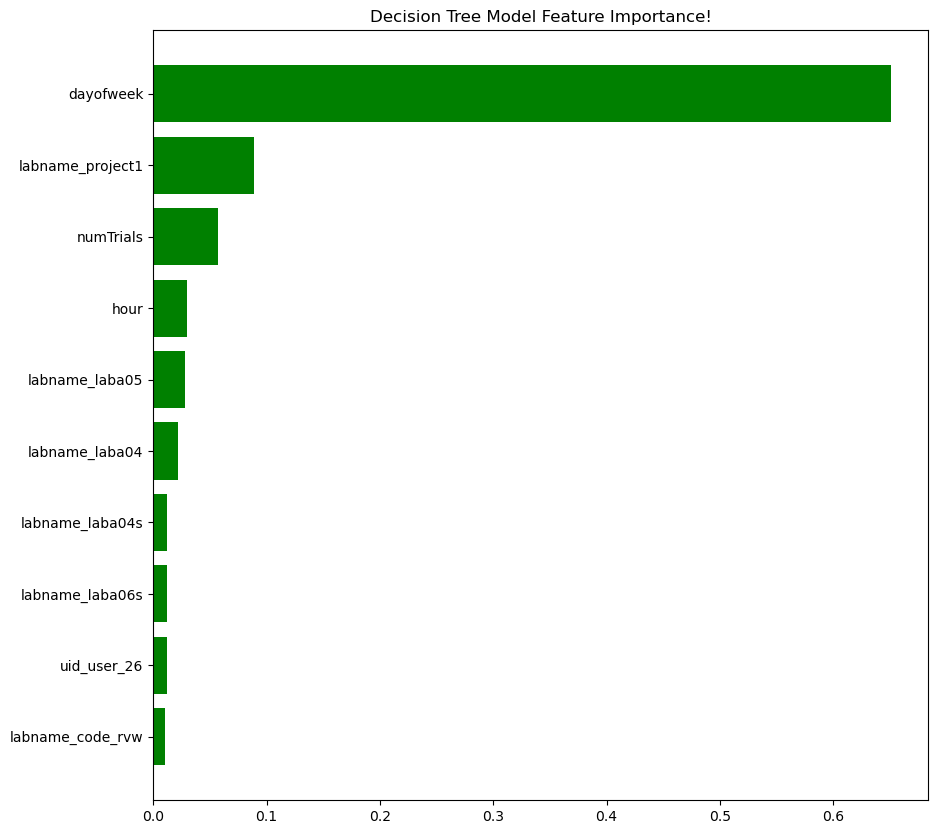

In [ ]:
n = 10
feature_names = X_train.columns
importances = ran_forest_model.feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,10))
plt.title('Decision Tree Model Feature Importance!')

plt.barh(range(n), importances[indices][:n],
         color="g", align="center")

plt.yticks(range(n), feature_names[indices][:n])
plt.gca().invert_yaxis()
plt.show()